# Einstein's Mission

Einstein Bannerjee is the name of a fictional character.

He will use artificial intelligence together with humanity's accumulated astronomical knowledge to discover, understand, and document interesting objects in the Universe.

In [20]:
# Cell 1 - Investigation target

TARGET_LABEL = 39

In [21]:
# Cell 2 - Import NED table

from astropy.table import Table

ned_table = Table.read(
    f"../data/catalogs/object{TARGET_LABEL}_ned.ecsv",
    format="ascii.ecsv"
)

In [22]:
# ============================================================
# Cell 3 - Imports
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
import astropy.units as u

In [23]:
# ============================================================
# Cell 4 - Load Einstein Object Profile
# ============================================================

profile = Table.read(
    f"../data/catalogs/object{TARGET_LABEL}_profile.ecsv",
    format="ascii.ecsv"
)

profile

Einstein Label,SIMBAD Name,Object Type,Measured Flux,Area (pixels),Semimajor Axis (pixels),Semiminor Axis (pixels),Orientation (deg),Eccentricity,Einstein RA (deg),Einstein Dec (deg),SIMBAD RA,SIMBAD Dec
int64,str26,str3,float64,int64,float64,float64,float64,float64,float64,float64,str18,str19
39,ATCDFS J033238.75-274632.5,Rad,46.78691118955612,56,2.653217020773862,1.3991502460330931,17.000210077987287,0.8496537049927184,53.16080319528244,-27.775437497555945,53.161458333333336,-27.775694444444447


In [28]:
# ============================================================
# Cell 5 - Load FITS Image
# ============================================================

fits_file = "../data/raw/mastDownload/HST/ib5x1fetq/ib5x1fetq_flt.fits"

hdul = fits.open(fits_file)

hdul.info()

Filename: ../data/raw/mastDownload/HST/ib5x1fetq/ib5x1fetq_flt.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     272   ()      
  1  SCI           1 ImageHDU       207   (1014, 1014)   float32   
  2  ERR           1 ImageHDU        48   (1014, 1014)   float32   
  3  DQ            1 ImageHDU        40   (1014, 1014)   int16   
  4  SAMP          1 ImageHDU        34   (1014, 1014)   int16   
  5  TIME          1 ImageHDU        34   (1014, 1014)   float32   
  6  HDRLET        1 NonstandardExtHDU     17   (5760,)      
  7  HDRLET        2 NonstandardExtHDU     17   (5760,)      
  8  HDRLET        3 NonstandardExtHDU     17   (8640,)      
  9  HDRLET        4 NonstandardExtHDU     17   (8640,)      
 10  WCSCORR       1 BinTableHDU     59   7R x 24C   [40A, I, A, 24A, 24A, 24A, 24A, D, D, D, D, D, D, D, D, 24A, 24A, D, D, D, D, J, 40A, 128A]   
 11  HDRLET        5 NonstandardExtHDU     17   (8640,)      
 12  HDRLET        6 Nons

In [29]:
# ============================================================
# Cell 6 - Convert Sky Coordinates to Pixels
# ============================================================

# Einstein position
einstein_coord = SkyCoord(
    profile["Einstein RA (deg)"][0] * u.deg,
    profile["Einstein Dec (deg)"][0] * u.deg,
    frame="icrs"
)

einstein_x, einstein_y = wcs.world_to_pixel(einstein_coord)

# NED positions
ra = np.array(ned_table["RA"], dtype=float)
dec = np.array(ned_table["DEC"], dtype=float)

ned_coords = SkyCoord(
    ra=ra * u.deg,
    dec=dec * u.deg,
    frame="icrs"
)

xpix, ypix = wcs.world_to_pixel(ned_coords)

ned_table["x_pixel"] = xpix
ned_table["y_pixel"] = ypix

print(f"Converted {len(ned_table)} NED objects to image coordinates.")

Converted 61 NED objects to image coordinates.


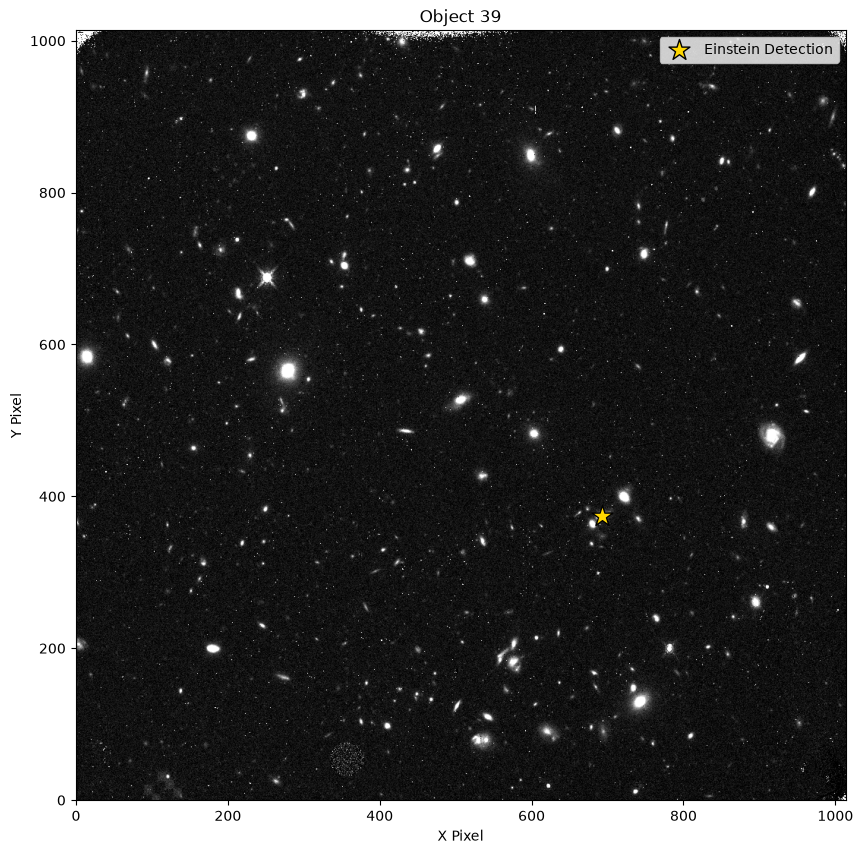

In [30]:
# ============================================================
# Cell 7 - Display Hubble Image
# ============================================================

plt.figure(figsize=(10,10))

plt.imshow(
    image,
    origin="lower",
    cmap="gray",
    vmin=np.percentile(image,5),
    vmax=np.percentile(image,99.5)
)

plt.scatter(
    einstein_x,
    einstein_y,
    marker="*",
    s=250,
    color="gold",
    edgecolor="black",
    label="Einstein Detection"
)

plt.title(f"Object {TARGET_LABEL}")

plt.xlabel("X Pixel")
plt.ylabel("Y Pixel")

plt.legend()

plt.show()

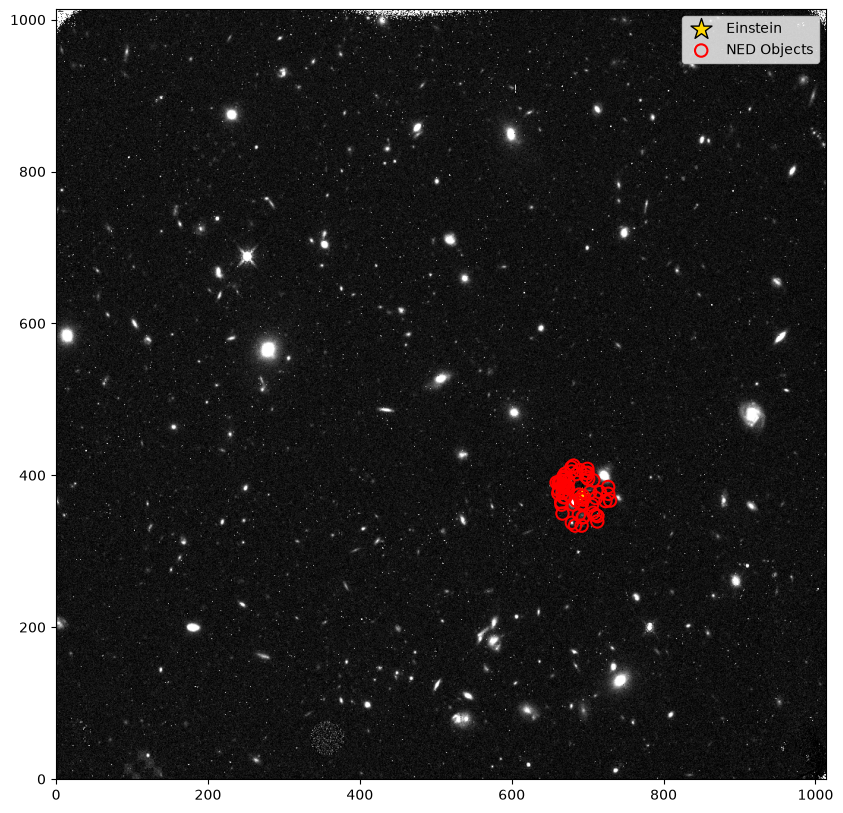

In [31]:
# ============================================================
# Cell 8 - Overlay NED Objects
# ============================================================

plt.figure(figsize=(10,10))

plt.imshow(
    image,
    origin="lower",
    cmap="gray",
    vmin=np.percentile(image,5),
    vmax=np.percentile(image,99.5)
)

# Einstein
plt.scatter(
    einstein_x,
    einstein_y,
    marker="*",
    s=250,
    color="gold",
    edgecolor="black",
    label="Einstein"
)

# NED
plt.scatter(
    ned_table["x_pixel"],
    ned_table["y_pixel"],
    facecolors="none",
    edgecolors="red",
    s=80,
    linewidth=1.5,
    label="NED Objects"
)

plt.legend()

plt.show()

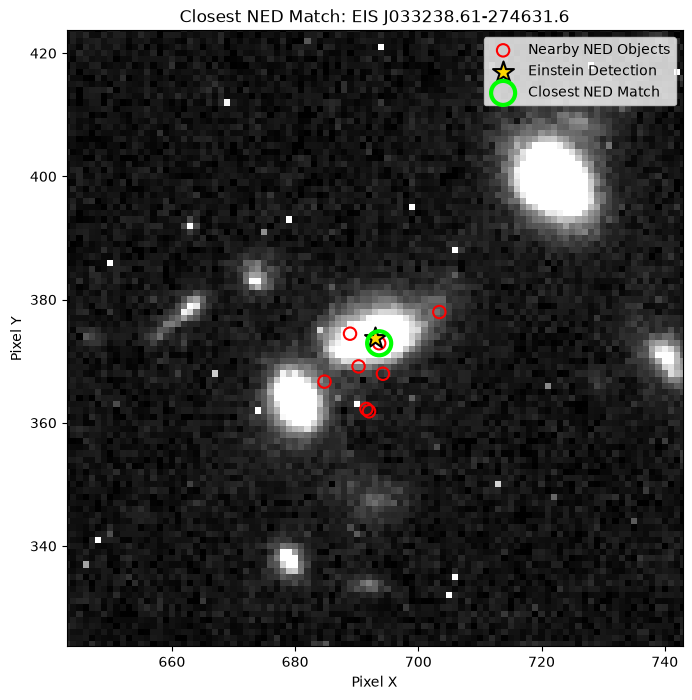


Nearby NED Objects (within 2 arcseconds)



Object Name,Type,Redshift,Einstein Separation (arcsec)
str30,object,float64,float64
EIS J033238.61-274631.6,G,0.621743,0.13537432927103826
WISEA J033238.57-274632.0,IrS,--,0.5456733533085534
[CVU2010] 46037,G,--,0.6502780101321016
ASPECS-LP.1 mm.Faint.C17,SmmS,--,0.7081466334602817
PEARS 089030:[SMP2008] KNOT 01,PofG,1.41,1.3851109472697753
SSTSL2 J033238.49-274631.9,G,2.55,1.388490681358657
GOODS-CDFS-MUSIC 11099,G,0.833048,1.423411159514202
[HSM2024] ALMA-HUDF 41,G,--,1.51395825592949


In [35]:
# ============================================================
# Cell 9 - Display the Closest NED Match
# ============================================================

# Find the closest NED object
closest = ned_table[np.argmin(ned_table["Einstein Separation (arcsec)"])]

# Keep only nearby NED objects (within 2 arcseconds)
nearby = ned_table[ned_table["Einstein Separation (arcsec)"] <= 2.0]

closest_x = closest["x_pixel"]
closest_y = closest["y_pixel"]

plt.figure(figsize=(8,8))

# Display the Hubble image
plt.imshow(
    image,
    origin="lower",
    cmap="gray",
    vmin=np.percentile(image,5),
    vmax=np.percentile(image,99.5)
)

# Plot nearby NED objects
plt.scatter(
    nearby["x_pixel"],
    nearby["y_pixel"],
    facecolors="none",
    edgecolors="red",
    s=80,
    linewidth=1.5,
    label="Nearby NED Objects"
)

# Plot Einstein detection
plt.scatter(
    einstein_x,
    einstein_y,
    marker="*",
    s=250,
    color="gold",
    edgecolor="black",
    linewidth=1.5,
    label="Einstein Detection"
)

# Highlight the closest NED match
plt.scatter(
    closest_x,
    closest_y,
    marker="o",
    s=300,
    facecolors="none",
    edgecolors="lime",
    linewidth=3,
    label="Closest NED Match"
)

# Zoom around the Einstein detection
half_width = 50

plt.xlim(einstein_x - half_width, einstein_x + half_width)
plt.ylim(einstein_y - half_width, einstein_y + half_width)

plt.title(f"Closest NED Match: {closest['Object Name']}")

plt.xlabel("Pixel X")
plt.ylabel("Pixel Y")

plt.legend(loc="upper right")

plt.show()

# ------------------------------------------------------------
# Display a summary table of nearby catalog objects
# ------------------------------------------------------------

columns = [
    "Object Name",
    "Type",
    "Redshift",
    "Einstein Separation (arcsec)"
]

summary = nearby[columns].copy()

summary.sort("Einstein Separation (arcsec)")

print("\nNearby NED Objects (within 2 arcseconds)\n")
summary

In [37]:
# ============================================================
# Cell 10 - Einstein Scientific Summary
# ============================================================

from collections import Counter

print("=" * 70)
print(f"Einstein Scientific Summary - Object {TARGET_LABEL}")
print("=" * 70)

print("\nPrimary NED Counterpart")
print("-" * 70)
print(f"Name        : {closest['Object Name']}")
print(f"Type        : {closest['Type']}")

if closest["Redshift"] is np.ma.masked:
    print("Redshift    : Unknown")
else:
    print(f"Redshift    : {closest['Redshift']:.6f}")

print(f"Separation  : {closest['Einstein Separation (arcsec)']:.3f} arcsec")

print("\nNearby NED Objects (within 2 arcseconds)")
print("-" * 70)
print(f"Number of nearby objects : {len(nearby)}")

# ------------------------------------------------------------
# Count object types
# ------------------------------------------------------------

types = []

for t in nearby["Type"]:
    if t is np.ma.masked:
        types.append("Unknown")
    else:
        types.append(str(t))

counts = Counter(types)

print("\nObject Types")
print("-" * 70)

for obj_type, number in sorted(counts.items()):
    print(f"{obj_type:<15} : {number}")

print("\nNearby Catalog Objects")
print("-" * 70)

summary = nearby[
    [
        "Object Name",
        "Type",
        "Redshift",
        "Einstein Separation (arcsec)"
    ]
].copy()

summary.sort("Einstein Separation (arcsec)")

print(summary)

print("\nScientific Interpretation")
print("-" * 70)

print(
    f"The Einstein detection is positionally consistent with "
    f"{closest['Object Name']}, classified as a {closest['Type']}."
)

print(
    f"The positional offset of "
    f"{closest['Einstein Separation (arcsec)']:.3f} arcseconds "
    f"indicates an excellent positional match."
)

if closest["Redshift"] is not np.ma.masked:
    print(
        f"The cataloged redshift (z = {closest['Redshift']:.6f}) "
        f"places the object at cosmological distance."
    )

print(
    f"A total of {len(nearby)} catalog objects lie within "
    f"2 arcseconds of the Einstein position, showing that this "
    f"region has been observed by multiple astronomical surveys "
    f"at different wavelengths."
)

print("\n" + "=" * 70)
print("End of Einstein Report")
print("=" * 70)

Einstein Scientific Summary - Object 39

Primary NED Counterpart
----------------------------------------------------------------------
Name        : EIS J033238.61-274631.6
Type        : G
Redshift    : 0.621743
Separation  : 0.135 arcsec

Nearby NED Objects (within 2 arcseconds)
----------------------------------------------------------------------
Number of nearby objects : 8

Object Types
----------------------------------------------------------------------
G               : 5
IrS             : 1
PofG            : 1
SmmS            : 1

Nearby Catalog Objects
----------------------------------------------------------------------
         Object Name           Type  Redshift  Einstein Separation (arcsec)
------------------------------ ---- ---------- ----------------------------
       EIS J033238.61-274631.6    G   0.621743          0.13537432927103826
     WISEA J033238.57-274632.0  IrS         --           0.5456733533085534
               [CVU2010] 46037    G         --        

In [38]:
# ============================================================
# Notebook Status
# ============================================================

from datetime import datetime

print("=" * 60)
print("Notebook Status")
print("=" * 60)

print("Status    : PASS")
print("Notebook  : 19_visual_catalog_cross_matching.ipynb")
print("Completed :", datetime.now().strftime("%Y-%m-%d %H:%M"))

Notebook Status
Status    : PASS
Notebook  : 19_visual_catalog_cross_matching.ipynb
Completed : 2026-07-19 21:20
